<a href="https://colab.research.google.com/github/ibel123/OIBSIP/blob/main/DataScience-Task1-IrisClassification/Iris_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Flower Classification

Oasis Infobyte SIP, Data Science Track, Task 1

This notebook trains a machine learning model to identify the species of an iris flower (Setosa, Versicolor, or Virginica) using its physical measurements: sepal length, sepal width, petal length, and petal width.

We will follow these steps:
1. Load the dataset
2. Explore the data (EDA)
3. Visualize the data
4. Discuss which features matter most
5. Split the data into training and testing sets
6. Train two different classification models
7. Evaluate both models
8. Pick the best model and explain why


## Step 1: Import the libraries we need

We import pandas for handling tables of data, matplotlib and seaborn for drawing charts, and scikit learn for the machine learning parts.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")


## Step 2: Load the Iris dataset

The Iris dataset comes built into scikit learn, so there is nothing to download. It contains 150 flower samples, 50 from each of the three species. Each sample has four measurements.

We turn it into a pandas DataFrame because DataFrames are easier to explore and plot.

In [ ]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 3: Explore the data (EDA)

Before building any model, we check basic facts about the data: its shape, its data types, whether anything is missing, and what the numbers look like on average.

In [ ]:
print("Shape of the dataset (rows, columns):", df.shape)


Shape of the dataset (rows, columns): (150, 5)


In [ ]:
print("Data types of each column:")
df.dtypes


Data types of each column:


,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,category


In [ ]:
print("Checking for missing values:")
df.isnull().sum()


Checking for missing values:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [ ]:
print("Descriptive statistics:")
df.describe()


Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The dataset has 150 rows and 5 columns (4 measurements plus the species label). There are no missing values, so we do not need to clean anything. The describe table shows the average, minimum, maximum, and spread of each measurement.

## Step 4: Visualize the data

Charts help us see patterns that plain numbers hide. We will use:
1. A pairplot, which draws every feature against every other feature, colored by species
2. Box plots, which show the spread of each measurement per species

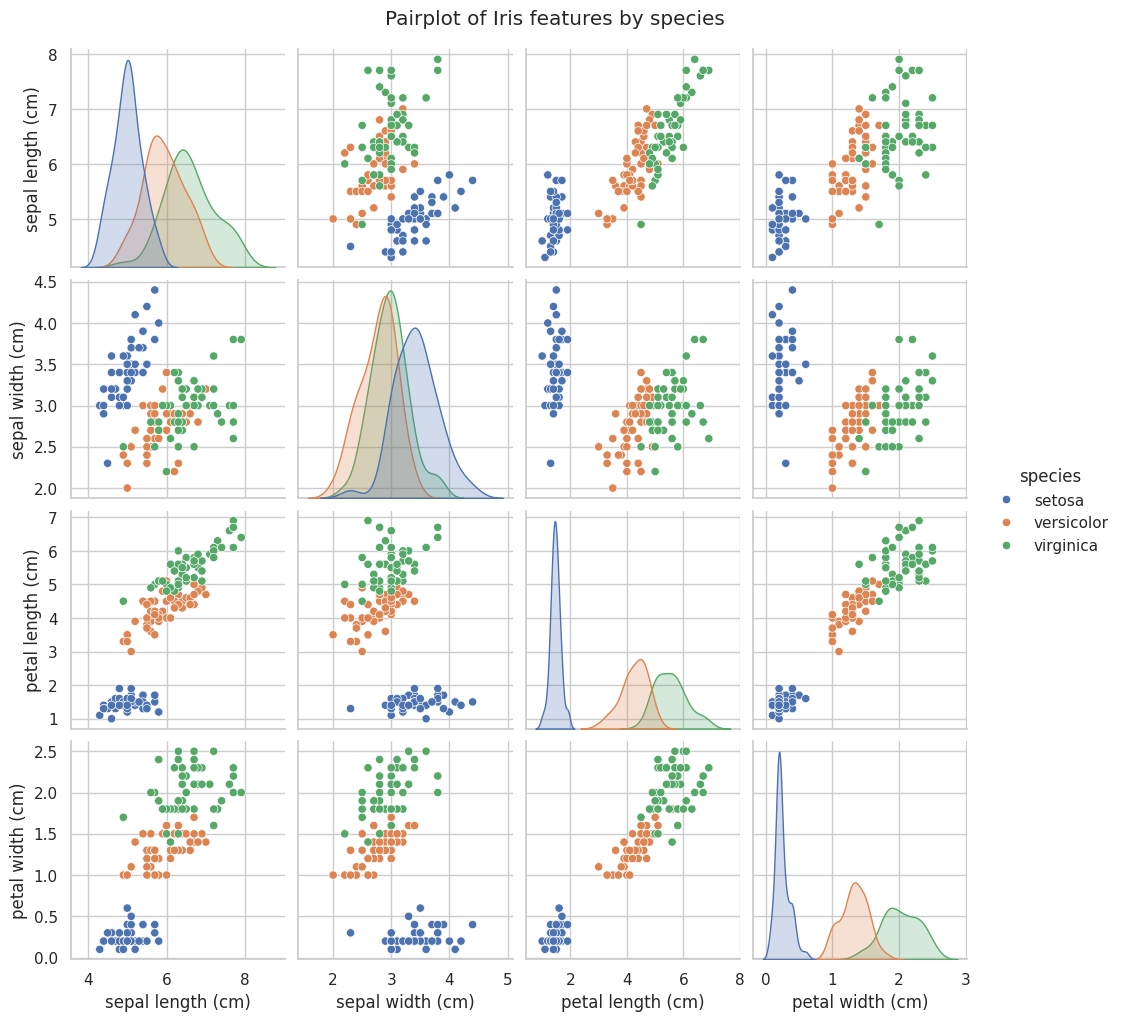

In [ ]:
sns.pairplot(df, hue="species")
plt.suptitle("Pairplot of Iris features by species", y=1.02)
plt.show()


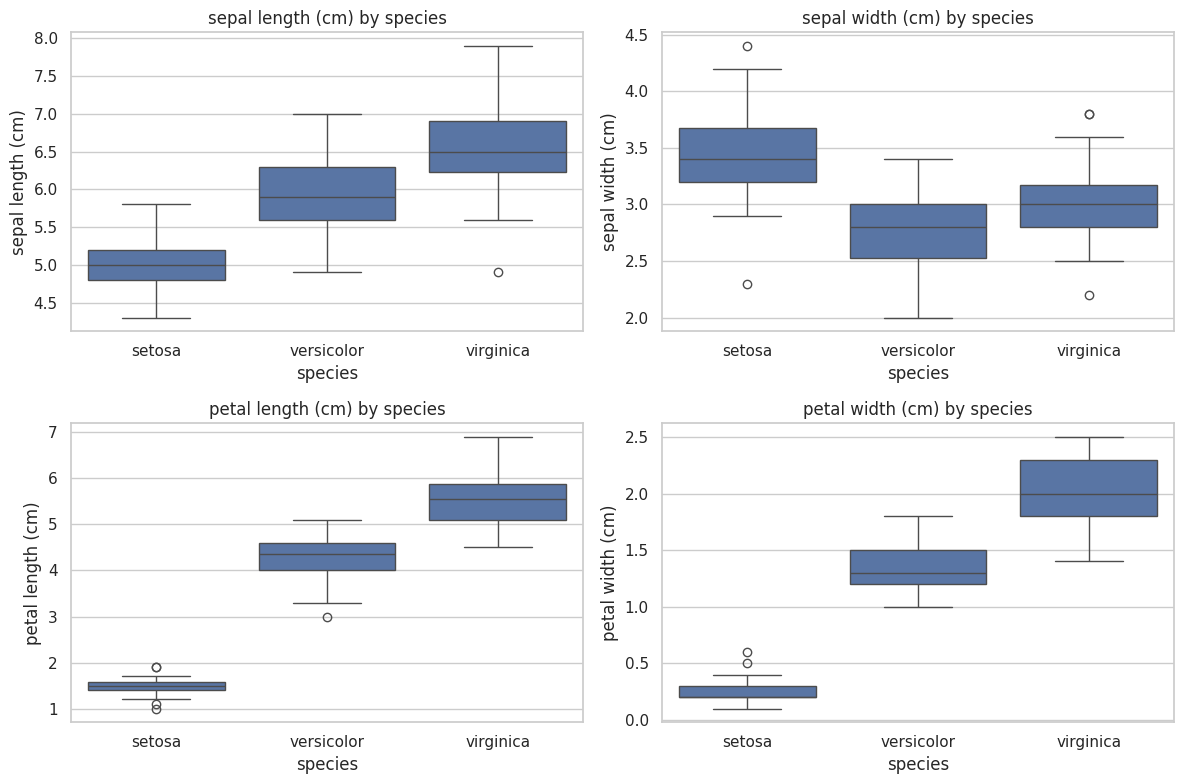

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="species", y=feature, ax=ax)
    ax.set_title(f"{feature} by species")

plt.tight_layout()
plt.show()


Setosa is clearly separated from the other two species on almost every measurement, especially petal length and petal width. Versicolor and Virginica overlap more, but petal measurements still separate them better than sepal measurements do.

## Step 5: Which features matter most?

Looking at the pairplot and box plots, petal length and petal width create the cleanest separation between species. Sepal length and sepal width overlap much more between Versicolor and Virginica, so they carry less useful information on their own.

We still keep all four features when training the models below, since scikit learn's classifiers can weigh each feature automatically, but this discussion explains why petal measurements are expected to matter most.

## Step 6: Split the data into training and testing sets

We train the model on part of the data (80 percent) and test it on data it has never seen (20 percent). This tells us how well the model generalizes rather than just memorizing the training examples.

In [ ]:
X = df[iris.feature_names]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


We use `stratify=y` so that each species is represented proportionally in both the training and testing sets. We use `random_state=42` so that the split is reproducible if you run the notebook again.

## Step 7: Train two different classifiers

We will train two well known classification algorithms and compare them:
1. Logistic Regression, a simple and fast linear model
2. K Nearest Neighbors (KNN), which classifies a flower based on the species of the most similar flowers in the training data

In [ ]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

log_reg_preds = log_reg.predict(X_test)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_preds = knn.predict(X_test)


## Step 8: Evaluate both models

For each model we look at:
1. Accuracy, the percentage of correct predictions
2. A confusion matrix, which shows exactly which species get mixed up with which
3. A classification report, which shows precision, recall, and F1 score for each species

In [ ]:
print("Logistic Regression accuracy:", accuracy_score(y_test, log_reg_preds))
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, log_reg_preds, labels=iris.target_names))
print()
print("Classification report:")
print(classification_report(y_test, log_reg_preds))


Logistic Regression accuracy: 0.9666666666666667

Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
print("KNN accuracy:", accuracy_score(y_test, knn_preds))
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, knn_preds, labels=iris.target_names))
print()
print("Classification report:")
print(classification_report(y_test, knn_preds))


KNN accuracy: 1.0

Confusion matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Visual confusion matrices

A heatmap makes the confusion matrix easier to read at a glance.

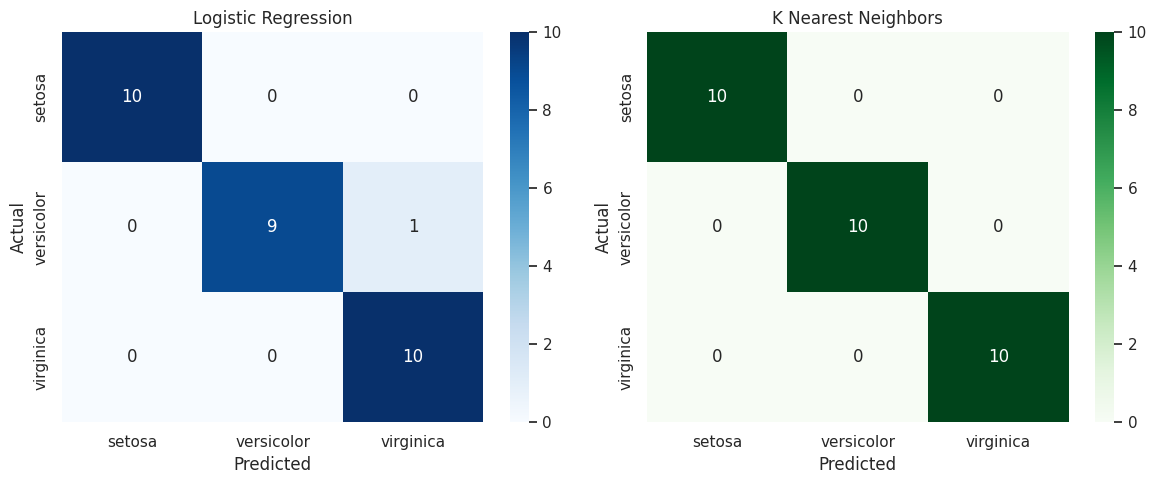

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, log_reg_preds, labels=iris.target_names)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_knn = confusion_matrix(y_test, knn_preds, labels=iris.target_names)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens",
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[1])
axes[1].set_title("K Nearest Neighbors")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


## Step 9: Which model performed best?

KNN achieved an accuracy of 100 percent while Logistic Regression achieved 96.7 percent on the test set, so KNN is declared the best performing model for this task. This is likely because the Iris species form fairly tight clusters in feature space, which suits KNN's approach of looking at the nearest neighbors.